# Cu-64 nel nucleo: microdosimetria → MKM → LQ → S(N) e RBE(N)

Metti questo notebook nella **radice del progetto** (dove c'è la cartella `runs/`) ed esegui le celle in ordine.
Il passo lento è uno solo (la cella *"Campionamento delle dosi"*): il risultato viene salvato in `cache_dosi.npz`,
quindi puoi cambiare pesi, `alpha_0`, `beta`, `G` e rifare grafici e tabelle in pochi secondi.

## 0. Parametri

In [2]:
import glob, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FILES = sorted(glob.glob("runs/run_*/yz.root"))
TREE = "yz"

# --- modello ---
R_d, R_n = 0.420, 4.0        # um   raggio dominio (= /microyz/det/Radius) e raggio nucleo
y0 = 150.0                   # keV/um  saturazione MKM
alpha_0, beta = 0.147, 0.02  # Gy^-1, Gy^-2 (raggi X)
G = 1.0                      # Lea-Catcheside: 1 = dose istantanea, <1 se protratta.
                             # L'RBE e' sempre rispetto a raggi X con lo stesso G (isola l'effetto della qualita' della radiazione)
rho = 1e-15                  # kg/um^3
KEV_J, EV_J = 1.602176634e-16, 1.602176634e-19
S_TARGET = 0.10
K_CONV = KEV_J / (rho * np.pi * R_d**2)     # Gy per keV/um

# --- statistica ---
N_SIM = 400                  # cellule virtuali per pool
N_POINTS = 60                # punti sull'asse N
N_BOOT = 20                  # pool bootstrap (solo se hai UN file)
SEED = 12345
WEIGHT_MODES = ("1/n", "N/n")   # 1/n: correzione dentro l'evento; N/n: anche tra eventi
PLOT_MODE = "N/n"

print(f"{len(FILES)} file trovati;  K_CONV = {K_CONV:.4f} Gy per keV/um")

10 file trovati;  K_CONV = 0.2891 Gy per keV/um


## 1. Lettura dei file

In [3]:
import uproot

cols = ["y", "nbHits", "nbScoredHits", "Nuclear_dose"]
dfs = [uproot.open(f)[TREE].arrays(cols, library="pd") for f in FILES]
print("eventi per file:", [len(d) for d in dfs])
dfs[0].head()

eventi per file: [20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000]


,y,nbHits,nbScoredHits,Nuclear_dose
0,1.810664,109.0,106.0,0.000618
1,2.733359,634.0,172.0,0.003388
2,0.734755,50.0,42.0,0.000281
3,0.181084,13.0,13.0,0.000061
4,10.309502,935.0,646.0,0.004976


## 2. Controlli
- **Allineamento:** l'energia nel nucleo (da `Nuclear_dose`) deve essere ≥ quella nel dominio (da `y`). Frazione attesa: 1.0000.
- **Seed:** i run devono avere eventi diversi.

In [4]:
def check_alignment(df, label=""):
    m_nucl = 1e3 * 4/3 * np.pi * (R_n * 1e-6) ** 3
    e_nucl = df["Nuclear_dose"].to_numpy() * m_nucl / EV_J     # eV nel nucleo
    eps = df["y"].to_numpy() * (4 * R_d / 3 * 1000.0)          # eV nel dominio
    ok = np.mean(e_nucl >= eps * (1 - 1e-3) - 0.5)
    print(f"[check] {label}: righe coerenti = {ok:.4f}")
    return ok

check_ok = [check_alignment(d, f) for f, d in zip(FILES, dfs)]

seed_msg = "un solo file (non verificabile)"
if len(dfs) > 1:
    heads = [d["y"].to_numpy()[:200].tobytes() for d in dfs]
    seed_msg = "run tutti diversi" if len(set(heads)) == len(heads) else "ATTENZIONE: run identici, seed non cambiati!"
print("[seed]", seed_msg)

[check] runs/run_01/yz.root: righe coerenti = 1.0000
[check] runs/run_02/yz.root: righe coerenti = 1.0000
[check] runs/run_03/yz.root: righe coerenti = 1.0000
[check] runs/run_04/yz.root: righe coerenti = 1.0000
[check] runs/run_05/yz.root: righe coerenti = 1.0000
[check] runs/run_06/yz.root: righe coerenti = 1.0000
[check] runs/run_07/yz.root: righe coerenti = 1.0000
[check] runs/run_08/yz.root: righe coerenti = 1.0000
[check] runs/run_09/yz.root: righe coerenti = 1.0000
[check] runs/run_10/yz.root: righe coerenti = 1.0000
[seed] run tutti diversi


## 3. Pool (un pool = una simulazione indipendente)

In [5]:
def make_pools(dfs, rng):
    if len(dfs) > 1:
        return dfs
    df = dfs[0]
    print(f"un solo file: uso {N_BOOT} pool bootstrap")
    return [df.iloc[rng.integers(0, len(df), len(df))].reset_index(drop=True) for _ in range(N_BOOT)]

rng = np.random.default_rng(SEED)
pools = make_pools(dfs, rng)
print(len(pools), "pool")

10 pool


## 4. Microdosimetria: y_F, y_D, y*
Per ogni pool e per ciascuno schema di peso. Gli errori (`sem`) sono tra pool.

In [6]:
def weights(df, mode):
    n = df["nbScoredHits"].to_numpy(float)
    big_n = df["nbHits"].to_numpy(float)
    return 1.0 / n if mode == "1/n" else big_n / n

def micro(df, mode):
    y = df["y"].to_numpy()
    w = weights(df, mode)
    y_f = np.sum(w * y) / np.sum(w)
    y_d = np.sum(w * y**2) / np.sum(w * y)
    y_star = np.sum(w * y0**2 * (1.0 - np.exp(-(y / y0) ** 2))) / np.sum(w * y)
    return y_f, y_d, y_star

rows = []
for i, p in enumerate(pools):
    for mode in WEIGHT_MODES:
        yf, yd, ys = micro(p, mode)
        rows.append(dict(pool=i, peso=mode, yF=yf, yD=yd, ystar=ys,
                         alpha=alpha_0 + beta * K_CONV * ys))
tab_micro = pd.DataFrame(rows)
tab_micro.groupby("peso")[["yF", "yD", "ystar", "alpha"]].agg(["mean", "sem"])

yF                  yD               ystar               alpha  \
          mean       sem      mean       sem      mean       sem      mean   
peso                                                                         
1/n   0.187951  0.000595  1.888969  0.007032  1.887031  0.007018  0.157911   
N/n   1.127767  0.005320  4.804801  0.010795  4.798184  0.010761  0.174744   

                
           sem  
peso            
1/n   0.000041  
N/n   0.000062

## 5. Spettri pesati f(y) e d(y) (tutti i run insieme)

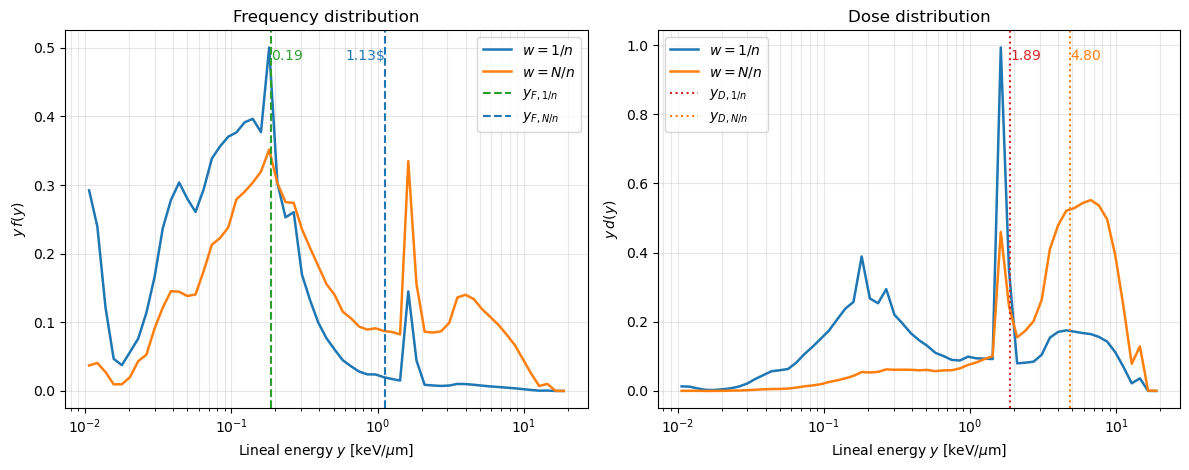

In [7]:
yF_Nn = 1.127767
yD_Nn = 4.804801

yF_1n = 0.187951
yD_1n = 1.888969

allp = pd.concat(pools, ignore_index=True)

bins = np.logspace(-2, np.log10(20), 60)
x = np.sqrt(bins[:-1] * bins[1:])
dln = np.diff(np.log(bins))
labels = {"1/n": r"$w = 1/n$", "N/n": r"$w = N/n$"}

fig, ax = plt.subplots(1, 2, figsize=(12, 4.8))
for mode in WEIGHT_MODES:
    w = weights(allp, mode)
    y = allp["y"].to_numpy()
    f = np.histogram(y, bins=bins, weights=w)[0];     f = f / f.sum() / dln
    d = np.histogram(y, bins=bins, weights=w * y)[0]; d = d / d.sum() / dln
    ax[0].semilogx(x, f, lw=1.8, label=labels[mode])
    ax[1].semilogx(x, d, lw=1.8, label=labels[mode])

ax[0].axvline(yF_1n, linestyle="--", label=r"$y_{F,{1/n}}$", color="C2")
ax[0].text(yF_1n, 0.95, rf"${yF_1n:.2f}$",color="C2", verticalalignment="top", horizontalalignment="left",
transform=ax[0].get_xaxis_transform())

ax[0].axvline(yF_Nn, linestyle="--", label=r"$y_{F,{N/n}}$", color="C0")
ax[0].text(yF_Nn, 0.95, rf"{yF_Nn:.2f}$",color="C0", verticalalignment="top", horizontalalignment="right",
transform=ax[0].get_xaxis_transform())
ax[1].axvline(yD_1n, linestyle=":", label=r"$y_{D,{1/n}}$", color="C3")
ax[1].text(yD_1n, 0.95, rf"${yD_1n:.2f}$",color="C3", verticalalignment="top", horizontalalignment="left",
transform=ax[1].get_xaxis_transform())


ax[1].axvline(yD_Nn, linestyle=":", label=r"$y_{D,{N/n}}$", color="C1")
ax[1].text(yD_Nn, 0.95, rf"${yD_Nn:.2f}$",color="C1", verticalalignment="top", horizontalalignment="left",
transform=ax[1].get_xaxis_transform())


ax[0].set_title("Frequency distribution")
ax[1].set_title("Dose distribution")
ax[0].set_ylabel(r"$y\,f(y)$")
ax[1].set_ylabel(r"$y\,d(y)$")
for a in ax:
    a.set_xlabel(r"Lineal energy $y$ [keV/$\mu$m]")
    a.grid(alpha=0.3, which="both")
    a.legend()
plt.tight_layout()

# salvataggio: figura intera + i due pannelli separati
fig.savefig("spettri.png", dpi=200, bbox_inches="tight")
for k, nome in enumerate(["f_y.png", "d_y.png"]):
    box = ax[k].get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())
    fig.savefig(nome, dpi=200, bbox_inches=box)

plt.show()

## 6. Campionamento delle dosi (passo lento, una volta sola)
Ogni cellula virtuale accumula decadimenti uno dopo l'altro; la dose a N decadimenti è la somma cumulata delle dosi nucleari.
Una sola estrazione per cellula serve per tutti gli N.

In [8]:
def d_ref_at(s_target, g=None):
    """Dose di raggi X (alpha_0, beta*g) per avere S = s_target. Stesso G della radiazione studiata."""
    g = G if g is None else g
    b = beta * g
    return (-alpha_0 + np.sqrt(alpha_0**2 - 4 * b * np.log(s_target))) / (2 * b)

def sample_doses(dn, ns, rng):
    n_max = int(ns.max())
    idx = rng.integers(0, dn.size, size=(N_SIM, n_max), dtype=np.int32)
    cum = np.cumsum(dn[idx], axis=1)
    return cum[:, ns - 1].T                      # shape (len(ns), N_SIM)

dn_mean = np.mean([p["Nuclear_dose"].mean() for p in pools])
n_max = int(3 * d_ref_at(S_TARGET) / dn_mean)
ns = np.unique(np.linspace(1, n_max, N_POINTS).astype(int))
print(f"dose nucleare media per decadimento = {dn_mean:.3e} Gy ;  N da 1 a {n_max}")

t0 = time.time()
d_mats = []
for i, p in enumerate(pools):
    d_mats.append(sample_doses(p["Nuclear_dose"].to_numpy(), ns, rng))
    print(f"pool {i + 1}/{len(pools)}  ({time.time() - t0:.0f} s)")
d_mats = np.array(d_mats)                       # (pool, N, cellule)
np.savez("cache_dosi.npz", ns=ns, d_mats=d_mats)

dose nucleare media per decadimento = 1.541e-03 Gy ;  N da 1 a 14923
pool 1/10  (3 s)
pool 2/10  (3 s)
pool 3/10  (4 s)
pool 4/10  (5 s)
pool 5/10  (5 s)
pool 6/10  (6 s)
pool 7/10  (6 s)
pool 8/10  (7 s)
pool 9/10  (8 s)
pool 10/10  (9 s)


*Solo se riavvii il kernel:* non rifare il campionamento, ricarica la cache (e rilancia le celle 0-4).

In [9]:
# cache = np.load("cache_dosi.npz"); ns = cache["ns"]; d_mats = cache["d_mats"]

## 7. LQ + MKM: S(N), RBE(N), N10, D10 (veloce)

In [10]:
def lq(d_mat, alpha, g=None):
    g = G if g is None else g
    e = alpha * d_mat + beta * g * d_mat**2
    s = np.exp(-e)
    d_ref = (-alpha_0 + np.sqrt(alpha_0**2 + 4 * beta * g * e)) / (2 * beta * g)   # raggi X con lo stesso G
    rbe = np.where(d_mat > 0, d_ref / np.where(d_mat > 0, d_mat, 1.0), np.nan)
    return s, rbe

def crossing(ns, s_mean, d_mean, target=S_TARGET):
    if s_mean.min() > target:
        return np.nan, np.nan                    # S non arriva al target nella griglia
    s = np.maximum(np.minimum.accumulate(s_mean), 1e-300)
    ls = np.log(s)
    return (np.interp(np.log(target), ls[::-1], ns[::-1]),
            np.interp(np.log(target), ls[::-1], d_mean[::-1]))

def analyze(df, d_mat, mode, g=None):
    g = G if g is None else g
    y_f, y_d, y_star = micro(df, mode)
    alpha = alpha_0 + beta * K_CONV * y_star
    s, rbe = lq(d_mat, alpha, g)
    s_mean, d_mean = s.mean(axis=1), d_mat.mean(axis=1)
    n10, d10 = crossing(ns, s_mean, d_mean)
    return dict(S=s_mean, S_cell=s.std(axis=1),
                rbe=np.nanmean(rbe, axis=1), rbe_cell=np.nanstd(rbe, axis=1), D=d_mean,
                yF=y_f, yD=y_d, ystar=y_star, alpha=alpha,
                N10=n10, D10=d10, rbe10=d_ref_at(S_TARGET, g) / d10, rbe_max=alpha / alpha_0)

def aggregate(results):
    k = len(results)
    agg = {}
    for key in ("S", "rbe", "D"):
        arr = np.array([r[key] for r in results])
        agg[key] = arr.mean(axis=0)
        agg[key + "_sem"] = arr.std(axis=0, ddof=1) / np.sqrt(k)
    for key in ("S_cell", "rbe_cell"):
        agg[key] = np.mean([r[key] for r in results], axis=0)
    for key in ("yF", "yD", "ystar", "alpha", "N10", "D10", "rbe10", "rbe_max"):
        v = np.array([r[key] for r in results])
        agg[key] = v.mean()
        agg[key + "_sem"] = v.std(ddof=1) / np.sqrt(k)
    return agg

results = {m: [analyze(p, dm, m) for p, dm in zip(pools, d_mats)] for m in WEIGHT_MODES}
agg = {m: aggregate(results[m]) for m in WEIGHT_MODES}

tab = pd.DataFrame({
    m: {"y_F": a["yF"], "y_D": a["yD"], "y*": a["ystar"], "alpha": a["alpha"], "RBE(D->0)": a["rbe_max"],
        "N10": a["N10"], "N10 sem": a["N10_sem"], "D10 [Gy]": a["D10"], "D10 sem": a["D10_sem"],
        "RBE10": a["rbe10"], "RBE10 sem": a["rbe10_sem"]}
    for m, a in agg.items()}).T
print(f"Dose X di riferimento per S=10%: {d_ref_at(S_TARGET):.4f} Gy")
tab

Dose X di riferimento per S=10%: 7.6667 Gy


,y_F,y_D,y*,alpha,RBE(D->0),N10,N10 sem,D10 [Gy],D10 sem,RBE10,RBE10 sem
1/n,0.187951,1.888969,1.887031,0.157911,1.074226,4854.695207,17.731941,7.487492,0.000603,1.023939,0.000083
N/n,1.127767,4.804801,4.798184,0.174744,1.188735,4680.140212,17.179356,7.218352,0.000935,1.062117,0.000138


## 8. Grafico: sopravvivenza e RBE

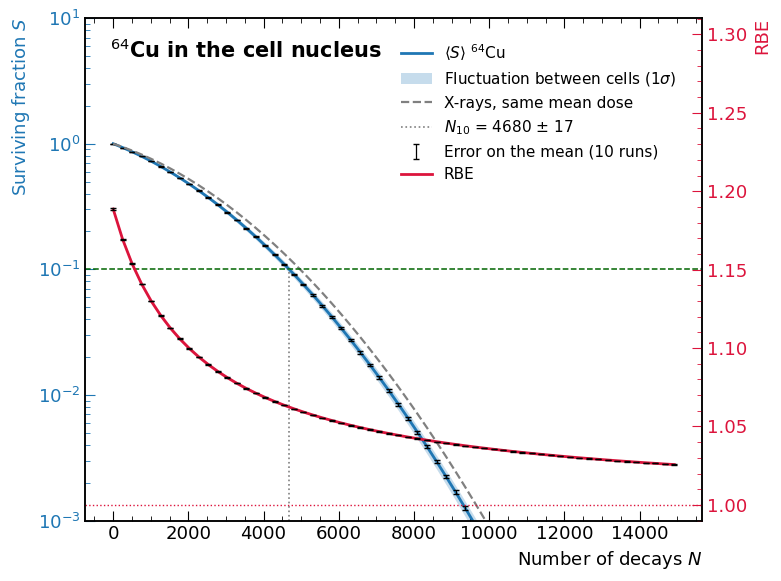

In [11]:
LAYOUT = "insieme"      # "insieme" = un solo grafico con due assi y ; "separati" = due figure indipendenti

STYLE = {
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "Liberation Sans", "DejaVu Sans"],
    "font.size": 13, "axes.linewidth": 1.1, "legend.frameon": False, "legend.fontsize": 11,
    "axes.grid": False,
}

a = agg[PLOT_MODE]
K = len(pools)
xlab = r"Number of decays $N$"
blue, red = "#1f77b4", "crimson"
band_lab = r"Fluctuation between cells ($1\sigma$)"
sem_lab = f"Error on the mean ({K} runs)"

def cern_axes(ax, right=True):
    """Tick verso l'interno su tutti i lati, tick minori, niente griglia."""
    ax.minorticks_on()
    ax.tick_params(which="both", direction="in", top=True, right=right)
    ax.tick_params(which="major", length=7)
    ax.tick_params(which="minor", length=3.5)

def label_box(ax):
    ax.text(0.04, 0.96, r"$^{64}$Cu in the cell nucleus", transform=ax.transAxes,
            fontsize=15, fontweight="bold", va="top")

def draw_S(ax):
    ax.plot(ns, a["S"], color=blue, lw=2, label=r"$\langle S\rangle$ $^{64}$Cu")
    ax.fill_between(ns, np.clip(a["S"] - a["S_cell"], 1e-12, None), a["S"] + a["S_cell"],
                    color=blue, alpha=0.25, lw=0, label=band_lab)
    ax.errorbar(ns, a["S"], yerr=a["S_sem"], fmt="none", ecolor="k", elinewidth=0.9, capsize=2, label=sem_lab)
    ax.plot(ns, np.exp(-alpha_0 * a["D"] - beta * G * a["D"] ** 2), "--", color="gray", lw=1.6,
            label="X-rays, same mean dose")
    ax.axhline(S_TARGET, color="darkgreen", ls="--", lw=1.1)
    ax.vlines(a["N10"], 1e-3, S_TARGET, colors="gray", linestyles=":", lw=1.2,
              label=rf"$N_{{10}}$ = {a['N10']:.0f} $\pm$ {a['N10_sem']:.0f}")
    ax.set_yscale("log")
    ax.set_ylim(1e-3, 1e1)

def draw_RBE(ax, labelled):
    ax.plot(ns, a["rbe"], color=red, lw=2, label="RBE")
    ax.fill_between(ns, a["rbe"] - a["rbe_cell"], a["rbe"] + a["rbe_cell"], color=red, alpha=0.25, lw=0,
                    label=band_lab if labelled else None)
    ax.errorbar(ns, a["rbe"], yerr=a["rbe_sem"], fmt="none", ecolor="k", elinewidth=0.9, capsize=2,
                label=sem_lab if labelled else None)
    ax.axhline(1.0, color=red, ls=":", lw=1)
    top = 0.99 + (a["rbe"].max() - 0.99) / 0.62       # la curva occupa ~60% dell'altezza: spazio per testo e legenda
    ax.set_ylim(0.99, top)

with plt.rc_context(STYLE):
    if LAYOUT == "insieme":
        fig, ax = plt.subplots(figsize=(8, 6))
        ax_r = ax.twinx()
        draw_S(ax)
        draw_RBE(ax_r, labelled=False)
        cern_axes(ax, right=False)
        cern_axes(ax_r, right=True)
        ax_r.tick_params(which="both", top=False)
        ax.set_xlabel(xlab, loc="right")
        ax.set_ylabel(r"Surviving fraction $S$", loc="top", color=blue)
        ax.tick_params(axis="y", which="both", colors=blue)
        ax_r.set_ylabel("RBE", loc="top", color=red)
        ax_r.tick_params(axis="y", which="both", colors=red)
        label_box(ax)
        h1, l1 = ax.get_legend_handles_labels()
        h2, l2 = ax_r.get_legend_handles_labels()
        ax.legend(h1 + h2, l1 + l2, loc="upper right", bbox_to_anchor=(0.98, 0.98))
        fig.tight_layout()
        fig.savefig("cu64_S_RBE.png", dpi=200, bbox_inches="tight")
        plt.show()

    else:
        fig1, ax1 = plt.subplots(figsize=(7, 5.5))
        draw_S(ax1)
        cern_axes(ax1)
        ax1.set_xlabel(xlab, loc="right")
        ax1.set_ylabel(r"Surviving fraction $S$", loc="top")
        label_box(ax1)
        ax1.legend(loc="upper right", bbox_to_anchor=(0.98, 0.98))
        fig1.tight_layout()
        fig1.savefig("S_N.png", dpi=200, bbox_inches="tight")
        plt.show()

        fig2, ax2 = plt.subplots(figsize=(7, 5.5))
        draw_RBE(ax2, labelled=True)
        cern_axes(ax2)
        ax2.set_xlabel(xlab, loc="right")
        ax2.set_ylabel("RBE", loc="top")
        label_box(ax2)
        ax2.legend(loc="upper right", bbox_to_anchor=(0.98, 0.98))
        fig2.tight_layout()
        fig2.savefig("RBE_N.png", dpi=200, bbox_inches="tight")
        plt.show()

## 9. (Opzionale) Effetto della riparazione: scansione di G
Dose protratta in ore (emivita del Cu-64 ≈ 12.7 h) → il termine quadratico si riduce (`G < 1`). L'RBE resta rispetto a raggi X con lo stesso `G`.
Usa la cache delle dosi, quindi è istantaneo. Con `G` piccolo S può non arrivare al 10% nella griglia di N: in quel caso compare `NaN`.

In [12]:
rows = []
for g in (1.0, 0.5, 0.2, 0.1, 0.05):
    res = [analyze(p, dm, PLOT_MODE, g=g) for p, dm in zip(pools, d_mats)]
    n10 = np.array([r["N10"] for r in res]); r10 = np.array([r["rbe10"] for r in res])
    rows.append(dict(G=g, N10=np.nanmean(n10), N10_sem=np.nanstd(n10, ddof=1) / np.sqrt(len(n10)),
                     RBE10=np.nanmean(r10)))
tab_G = pd.DataFrame(rows)
tab_G

,G,N10,N10_sem,RBE10
0,1.00,4680.140212,17.179356,1.062117
1,0.50,5689.643669,20.771227,1.083842
2,0.20,6876.967989,25.608826,1.116899
3,0.10,7542.816975,28.099303,1.140728
4,0.05,7984.390662,29.920804,1.159581


## 10. Riepilogo da copiare
Stampa in testo tutti i risultati delle celle precedenti, così puoi incollarli in una volta sola.

In [13]:
a = agg[PLOT_MODE]
allp = pd.concat(pools, ignore_index=True)
yy = allp["y"].to_numpy()

print("=" * 78)
print("RIEPILOGO ANALISI Cu-64")
print("=" * 78)
print(f"File: {len(FILES)} | eventi per file: {[len(d) for d in dfs]}")
print(f"Check allineamento (frazione righe coerenti): {[round(float(c), 4) for c in check_ok]}")
print(f"Seed: {seed_msg}")
print(f"Parametri: R_d={R_d} um, R_n={R_n} um, y0={y0}, alpha_0={alpha_0}, beta={beta}, G={G}, K_CONV={K_CONV:.4f}")
print(f"Statistica: N_SIM={N_SIM}, N_POINTS={N_POINTS}, pool={len(pools)}, N max={int(ns.max())}")
print(f"Dose nucleare media per decadimento = {dn_mean:.4e} Gy")
print(f"Dose X di riferimento per S=10%: {d_ref_at(S_TARGET):.4f} Gy")

print("\n--- Distribuzione di y (tutti i run) ---")
print(f"y: media={yy.mean():.4f}, mediana={np.median(yy):.4f}, max={yy.max():.3f} keV/um")
for mode in WEIGHT_MODES:
    w = weights(allp, mode)
    print(f"peso {mode:>3}: eventi con y>10 keV/um = {np.mean(yy > 10):.4f} (non pesato), "
          f"{w[yy > 10].sum() / w.sum():.4f} (pesato)")

print("\n--- Microdosimetria (media e sem tra pool) ---")
print(tab_micro.groupby("peso")[["yF", "yD", "ystar", "alpha"]].agg(["mean", "sem"]).round(5).to_string())

print("\n--- Risultati finali per schema di peso ---")
print(tab.round(5).to_string())

print(f"\n--- Curva S(N), RBE(N) (peso {PLOT_MODE}), 10 punti ---")
sel = np.linspace(0, len(ns) - 1, 10).astype(int)
curve = pd.DataFrame({
    "N": ns[sel], "D_media[Gy]": a["D"][sel],
    "S": a["S"][sel], "S_sem": a["S_sem"][sel], "S_cell": a["S_cell"][sel],
    "RBE": a["rbe"][sel], "RBE_sem": a["rbe_sem"][sel], "RBE_cell": a["rbe_cell"][sel]})
print(curve.round(5).to_string(index=False))

print(f"\n--- Scansione G (peso {PLOT_MODE}) ---")
try:
    print(tab_G.round(4).to_string(index=False))
except NameError:
    print("(cella 9 non eseguita)")

RIEPILOGO ANALISI Cu-64
File: 10 | eventi per file: [20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000]
Check allineamento (frazione righe coerenti): [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
Seed: run tutti diversi
Parametri: R_d=0.42 um, R_n=4.0 um, y0=150.0, alpha_0=0.147, beta=0.02, G=1.0, K_CONV=0.2891
Statistica: N_SIM=400, N_POINTS=60, pool=10, N max=14923
Dose nucleare media per decadimento = 1.5412e-03 Gy
Dose X di riferimento per S=10%: 7.6667 Gy

--- Distribuzione di y (tutti i run) ---
y: media=2.0412, mediana=0.9619, max=18.560 keV/um
peso 1/n: eventi con y>10 keV/um = 0.0234 (non pesato), 0.0003 (pesato)
peso N/n: eventi con y>10 keV/um = 0.0234 (non pesato), 0.0073 (pesato)

--- Microdosimetria (media e sem tra pool) ---
           yF                yD             ystar             alpha         
         mean      sem     mean      sem     mean      sem     mean      sem
peso                                                                    

In [14]:
m_nucl = 1e3 * 4/3 * np.pi * (R_n * 1e-6) ** 3
E_nucl = allp["Nuclear_dose"] * m_nucl / EV_J            # eV nel nucleo, per evento
eps = allp["y"] * (4 * R_d / 3 * 1000.0)                 # eV nel dominio

print(f"media E_nucleo per evento        : {E_nucl.mean():.2f} eV")
print(f"media eps * (N/n)  : {(eps * allp['nbHits'] / allp['nbScoredHits']).mean():.2f} eV   (atteso = E_nucleo)")
print(f"media eps * (1/n)         : {(eps / allp['nbScoredHits']).mean():.2f} eV")

media E_nucleo per evento        : 2578.74 eV
media eps * (N/n)  : 2579.79 eV   (atteso = E_nucleo)
media eps * (1/n)         : 9.93 eV


In [15]:
k = len(pools)
res = results[PLOT_MODE]
i10 = np.argmin(abs(ns - agg[PLOT_MODE]["N10"]))

S_pool = np.array([r["S"][i10] for r in res])         # <S> di ogni pool
S_cell = np.array([r["S_cell"][i10] for r in res])    # dispersione tra cellule dentro ogni pool

print(f"<S> a N10                        : {S_pool.mean():.5f}")
print(f"dispersione tra cellule (sigma)  : {S_cell.mean():.5f}   (variabilità, NON è un errore)")
print(f"errore sulla media (tra pool)    : {S_pool.std(ddof=1) / np.sqrt(k):.6f}")
print(f"  rumore del resampling per pool : {S_cell.mean() / np.sqrt(N_SIM):.6f}   (deve essere << dispersione tra pool = {S_pool.std(ddof=1):.6f})")
print(f"IC 95% (t, {k-1} g.l.)           : ± {2.262 * S_pool.std(ddof=1) / np.sqrt(k):.6f}")

<S> a N10                        : 0.09142
dispersione tra cellule (sigma)  : 0.00571   (variabilità, NON è un errore)
errore sulla media (tra pool)    : 0.001167
  rumore del resampling per pool : 0.000286   (deve essere << dispersione tra pool = 0.003691)
IC 95% (t, 9 g.l.)           : ± 0.002640


In [16]:
rng_c = np.random.default_rng(0)
sub = allp.iloc[rng_c.permutation(len(allp))]        # mescola, così ogni sottoinsieme mischia tutti i run

rows = []
for n in (2000, 5000, 10000, 20000, 50000, 100000, len(sub)):
    s = sub.iloc[:n]
    rows.append(dict(eventi=n,
                     y_star=micro(s, "N/n")[2],
                     dose_media_per_decadimento=s["Nuclear_dose"].mean()))
conv = pd.DataFrame(rows)
conv["y_star vs ultimo [%]"] = 100 * (conv["y_star"] / conv["y_star"].iloc[-1] - 1)
conv.round(5)

,eventi,y_star,dose_media_per_decadimento,y_star vs ultimo [%]
0,2000,4.60358,0.00150,-4.05997
1,5000,4.68724,0.00154,-2.31655
2,10000,4.70731,0.00154,-1.89818
3,20000,4.78258,0.00155,-0.32947
4,50000,4.76995,0.00154,-0.59273
5,100000,4.80270,0.00155,0.08965
6,200000,4.79839,0.00154,0.00000
